# Phase 5 — Petrophysical Log Review & CPI Evaluation

**Well**: 15/9-F-1 A · **Field**: Volve, Norwegian North Sea

Petrophysical crossplots are the primary QC tool for verifying log quality and deriving formation properties before rock physics analysis. This notebook produces four key diagnostic displays:

1. **Pickett plot** (NPHI vs RT, log–log) — saturation model verification, Rw confirmation, HC identification
2. **NPHI–RHOB lithology crossplot** — mineral identification, sand/shale separation, coal/carbonate outliers
3. **PEF–RHOB crossplot** — mineralogy cross-check (photoelectric factor)
4. **GR vs NPHI porosity crossplot** — clay volume estimation vs porosity

All crossplots use formation-top colour coding to separate the stratigraphic units.

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
WELL_FILE    = Path('../wells/15_9-F-1A.LAS')
TOPS_FILE    = Path('../wells/Volve_formation_tops.csv')
COMPUTED_IN  = Path('../wells/15_9-F-1A_computed.parquet')
FLAGS_IN     = Path('../wells/15_9-F-1A_flags.parquet')
DS_IN        = Path('../wells/15_9-F-1A_depthshift.parquet')

# ── Archie parameters (standard starting point) ──────────────────────────────
ARCHIE_A  = 1.0   # tortuosity factor
ARCHIE_M  = 2.0   # cementation exponent
ARCHIE_N  = 2.0   # saturation exponent

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family' : 'DejaVu Sans',
    'font.size'   : 9,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.dpi'  : 120,
})

## Step 5.1 — Load Data

In [2]:
# ── Load LAS ─────────────────────────────────────────────────────────────────
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.index.name = 'DEPTH_MD'

# ── Merge computed curves ─────────────────────────────────────────────────────
df = df.join(pd.read_parquet(COMPUTED_IN), how='left')
df = df.join(pd.read_parquet(FLAGS_IN),    how='left')

# Depth shift parquet: only join the shift-specific columns (not raw DT/DTS)
ds_df = pd.read_parquet(DS_IN)
ds_cols = [c for c in ds_df.columns if c not in df.columns]
df = df.join(ds_df[ds_cols], how='left')

# ── Formation tops ────────────────────────────────────────────────────────────
f1a = (
    pd.read_csv(TOPS_FILE)
    .query("`WELL` == 'NO 15/9-F-1 A'")
    .sort_values('DEPTH')
    .drop_duplicates(subset='DEPTH')
    .reset_index(drop=True)
)

# ── Helper ────────────────────────────────────────────────────────────────────
def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

# ── Log interval ─────────────────────────────────────────────────────────────
LOG_TOP, LOG_BASE = 2605, 3680
sub = df.loc[LOG_TOP:LOG_BASE].copy()

# ── Formation top dictionaries ────────────────────────────────────────────────
TOPS_MD = {
    'Ty Fm'        : 2621.5,
    'Shetland GP'  : 2770.6,
    'Hod Fm'       : 2987.0,
    'Draupne Fm'   : 3358.0,
    'Heather Fm'   : 3429.4,
    'Hugin Fm'     : 3435.0,
    'Sleipner Fm'  : 3500.2,
    'Skagerrak Fm' : 3543.7,
    'Smith Bank Fm': 3608.0,
}

# Colour map for formations on crossplots
FORM_COLORS = {
    'Ty Fm'        : '#2E86C1',
    'Shetland GP'  : '#85C1E9',
    'Hod Fm'       : '#AED6F1',
    'Draupne Fm'   : '#1A5276',
    'Heather Fm'   : '#784212',
    'Hugin Fm'     : '#E74C3C',
    'Sleipner Fm'  : '#1E8449',
    'Skagerrak Fm' : '#7D3C98',
    'Smith Bank Fm': '#B7950B',
}

# Assign formation label to each depth sample
top_mds = sorted(TOPS_MD.items(), key=lambda x: x[1])
sub['FORMATION'] = 'Above Ty'
for name, md_top in top_mds:
    sub.loc[sub.index >= md_top, 'FORMATION'] = name

print(f"Working interval: {LOG_TOP}–{LOG_BASE} m MD  ({len(sub):,} samples)")
print()
print("Samples per formation:")
for name, cnt in sub['FORMATION'].value_counts().sort_index().items():
    print(f"  {name:<20} {cnt:5,}")

Working interval: 2605–3680 m MD  (10,751 samples)

Samples per formation:
  Above Ty               165
  Draupne Fm             714
  Heather Fm              56
  Hod Fm               3,710
  Hugin Fm               652
  Shetland GP          2,164
  Skagerrak Fm           643
  Sleipner Fm            435
  Smith Bank Fm          721
  Ty Fm                1,491


## Step 5.2 — Pickett Plot (Porosity vs Resistivity)

The **Pickett plot** displays porosity (NPHI) on the y-axis versus resistivity (RT) on the x-axis, both on logarithmic scales. Archie's equation defines a straight line for clean, water-saturated rock:

$$\log R_t = \log(a \cdot R_w) - m \cdot \log\phi + \text{(correction for} S_w < 1\text{)}$$

On a Pickett plot:
- **Slope** = −1/m (cementation exponent)
- **x-intercept** at φ = 1 gives log(a·Rw) → provides an independent Rw estimate
- Points **to the right** of the Sw = 1 line are hydrocarbon-bearing (higher Rt than expected for brine)
- Shales plot at **low resistivity and low porosity** (tight cluster bottom-left)
- Coals plot at **high porosity and low resistivity** (top-left)

Rw at Hugin Fm: 0.0334 Ω·m


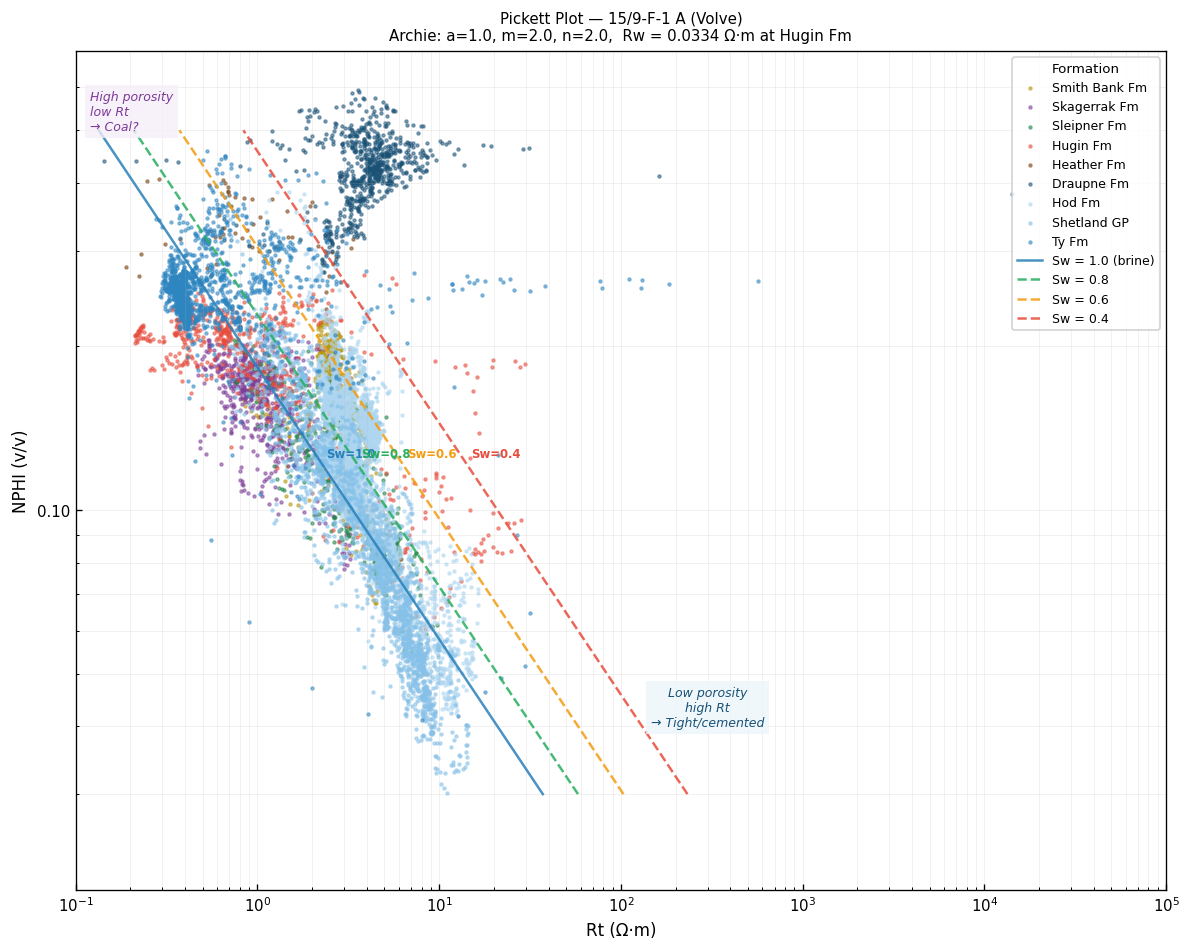


Reading the Pickett plot:
  → Water-saturated sands should plot on or near the Sw=1.0 trend
  → Points to the right of Sw=1.0 line are hydrocarbon-bearing
  → Slope of the water-sand trend = -1/m (cementation exponent check)


In [3]:
# ── Rw at mean reservoir temperature ──────────────────────────────────────────
# Use Rw from the computed parquet (Arps formula + Wright-Welex correction)
rw_hugin = sub.loc[nearest_idx(sub, 3437), 'RW']
print(f"Rw at Hugin Fm: {rw_hugin:.4f} Ω·m")

# ── Archie water-saturation lines ─────────────────────────────────────────────
phi_line = np.logspace(np.log10(0.03), np.log10(0.50), 200)

def rt_archie(phi, sw, rw=rw_hugin, a=ARCHIE_A, m=ARCHIE_M, n=ARCHIE_N):
    """Rt = a * Rw / (phi^m * sw^n)"""
    return a * rw / (phi**m * sw**n)

# ── Data mask: clean, valid points ────────────────────────────────────────────
mask = (sub['NPHI'] > 0.03) & sub['NPHI'].notna() & sub['RT'].notna() & (sub['RT'] > 0.1)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Points coloured by formation
for form_name in list(TOPS_MD.keys())[::-1]:
    fm = sub[(sub['FORMATION'] == form_name) & mask]
    if len(fm) == 0:
        continue
    ax.scatter(fm['RT'], fm['NPHI'],
               s=3, alpha=0.5, rasterized=True,
               color=FORM_COLORS.get(form_name, '#888888'),
               label=form_name)

# Archie lines
sw_vals = [1.0, 0.8, 0.6, 0.4]
sw_colors = ['#2980B9', '#27AE60', '#F39C12', '#E74C3C']
sw_labels = ['Sw = 1.0 (brine)', 'Sw = 0.8', 'Sw = 0.6', 'Sw = 0.4']
for sw, col, lab in zip(sw_vals, sw_colors, sw_labels):
    rt_line = rt_archie(phi_line, sw)
    ax.plot(rt_line, phi_line, color=col, lw=1.5,
            ls='-' if sw == 1.0 else '--', label=lab, alpha=0.85)
    # Label at middle of line
    mid = len(phi_line) // 2
    ax.annotate(f'Sw={sw:.1f}', xy=(rt_line[mid], phi_line[mid]),
                xytext=(4, 2), textcoords='offset points',
                fontsize=7, color=col, fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 100000)
ax.set_ylim(0.02, 0.70)
ax.set_xlabel('Rt (Ω·m)', fontsize=10)
ax.set_ylabel('NPHI (v/v)', fontsize=10)
ax.set_title(f'Pickett Plot — 15/9-F-1 A (Volve)\n'
             f'Archie: a={ARCHIE_A}, m={ARCHIE_M}, n={ARCHIE_N},  '
             f'Rw = {rw_hugin:.4f} Ω·m at Hugin Fm',
             fontsize=9)

# Grid
ax.grid(True, which='both', alpha=0.2, lw=0.5)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Legend — formations first, then Sw lines
leg1 = ax.legend(loc='upper right', fontsize=7.5, framealpha=0.85,
                  title='Formation', title_fontsize=8)

# Annotation: key interpretation zones
ax.text(0.12, 0.50, 'High porosity\nlow Rt\n→ Coal?',
        fontsize=7.5, color='#7D3C98', ha='left', style='italic',
        bbox=dict(facecolor='#F5EEF8', alpha=0.8, edgecolor='none', pad=3))
ax.text(300, 0.04, 'Low porosity\nhigh Rt\n→ Tight/cemented',
        fontsize=7.5, color='#1A5276', ha='center', style='italic',
        bbox=dict(facecolor='#EBF5FB', alpha=0.8, edgecolor='none', pad=3))

plt.tight_layout()
plt.show()
print()
print("Reading the Pickett plot:")
print("  → Water-saturated sands should plot on or near the Sw=1.0 trend")
print("  → Points to the right of Sw=1.0 line are hydrocarbon-bearing")
print("  → Slope of the water-sand trend = -1/m (cementation exponent check)")

## Step 5.3 — NPHI–RHOB Lithology Crossplot

The neutron-density crossplot is the primary **lithology identification** tool in petrophysics. Different minerals plot at characteristic positions defined by their matrix properties:

| Mineral | NPHI (v/v) | RHOB (g/cc) |
|---------|-----------|------------|
| Quartz (sandstone) | −0.02 | 2.65 |
| Calcite (limestone) | 0.00 | 2.71 |
| Dolomite | 0.02 | 2.87 |
| Coal | 0.45+ | 1.25–1.60 |
| Anhydrite | −0.01 | 2.96 |

For a porous formation, data points scatter between the mineral end-member and the pore-fluid (water) point (NPHI≈1.0, RHOB≈1.0 g/cc). **Gas effect** shifts points toward lower NPHI (gas has near-zero neutron response) and lower density, creating a characteristic 'gas crossover'.

**Shale** plots to the upper right (high NPHI, moderate–high RHOB) due to bound water in clay minerals.

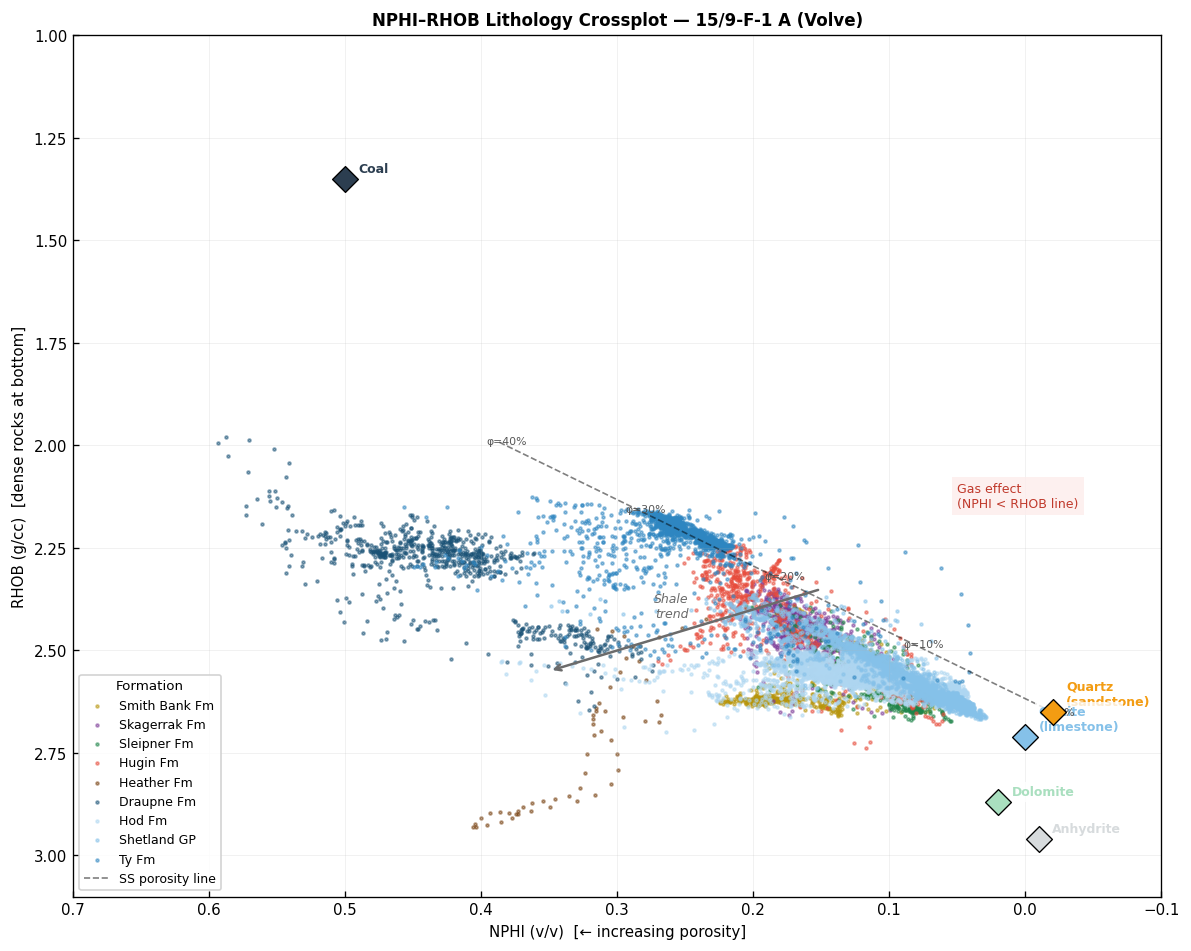

In [4]:
mask_nd = sub['NPHI'].notna() & sub['RHOB'].notna()

fig, ax = plt.subplots(figsize=(10, 8))

# Points by formation
for form_name in list(TOPS_MD.keys())[::-1]:
    fm = sub[(sub['FORMATION'] == form_name) & mask_nd]
    if len(fm) == 0:
        continue
    ax.scatter(fm['NPHI'], fm['RHOB'],
               s=3, alpha=0.5, rasterized=True,
               color=FORM_COLORS.get(form_name, '#888888'),
               label=form_name)

# ── Mineral end-member markers ────────────────────────────────────────────────
minerals = {
    'Quartz\n(sandstone)' : (-0.02, 2.65, '#F39C12'),
    'Calcite\n(limestone)': ( 0.00, 2.71, '#85C1E9'),
    'Dolomite'            : ( 0.02, 2.87, '#A9DFBF'),
    'Coal'                : ( 0.50, 1.35, '#2C3E50'),
    'Anhydrite'           : (-0.01, 2.96, '#D7DBDD'),
}
for min_name, (nphi_pt, rhob_pt, mcol) in minerals.items():
    ax.scatter(nphi_pt, rhob_pt, s=120, marker='D',
               color=mcol, edgecolors='black', lw=0.8, zorder=8)
    ax.annotate(min_name, xy=(nphi_pt, rhob_pt),
                xytext=(8, 4), textcoords='offset points',
                fontsize=7.5, fontweight='bold', color=mcol,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# ── Porosity lines (for sandstone matrix) ─────────────────────────────────────
# RHOB = RHOB_matrix × (1 - phi) + RHOB_fluid × phi
# NPHI ≈ phi  (for sandstone, liquid-filled)
phi_pts = np.array([0.0, 0.10, 0.20, 0.30, 0.40])
rhob_fluid, nphi_fluid = 1.00, 1.00  # water
rhob_matrix_ss, nphi_matrix_ss = 2.65, -0.02

rhob_line = rhob_matrix_ss * (1 - phi_pts) + rhob_fluid * phi_pts
nphi_line = nphi_matrix_ss * (1 - phi_pts) + nphi_fluid * phi_pts
ax.plot(nphi_line, rhob_line, 'k--', lw=1.0, alpha=0.5, label='SS porosity line')
for phi, nphi_pt, rhob_pt in zip(phi_pts, nphi_line, rhob_line):
    ax.text(nphi_pt + 0.008, rhob_pt, f'φ={phi:.0%}',
            fontsize=6.5, color='#555', va='center')

# ── Shale trend arrow ─────────────────────────────────────────────────────────
ax.annotate('', xy=(0.35, 2.55), xytext=(0.15, 2.35),
            arrowprops=dict(arrowstyle='->', color='#6B6B6B', lw=1.5))
ax.text(0.26, 2.42, 'Shale\ntrend', fontsize=7.5, color='#6B6B6B',
        ha='center', style='italic')

# ── Gas crossover region ──────────────────────────────────────────────────────
ax.annotate('Gas effect\n(NPHI < RHOB line)', xy=(0.05, 2.15),
            fontsize=7.5, color='#C0392B', ha='left',
            bbox=dict(facecolor='#FDEDEC', alpha=0.8, edgecolor='none', pad=3))

ax.set_xlim(-0.10, 0.70)
ax.set_ylim(1.00, 3.10)
ax.invert_yaxis()   # high density at bottom (conventional display)
ax.invert_xaxis()   # NPHI increases to the left (conventional)
ax.set_xlabel('NPHI (v/v)  [← increasing porosity]', fontsize=9)
ax.set_ylabel('RHOB (g/cc)  [dense rocks at bottom]', fontsize=9)
ax.set_title('NPHI–RHOB Lithology Crossplot — 15/9-F-1 A (Volve)',
             fontsize=10, fontweight='bold')
ax.legend(loc='lower left', fontsize=7.5, framealpha=0.85,
          title='Formation', title_fontsize=8)
ax.grid(True, alpha=0.2, lw=0.5)

plt.tight_layout()
plt.show()

## Step 5.4 — PEF–RHOB Mineralogy Crossplot

The **photoelectric factor** (PEF, also written PE) measures the average atomic number of the formation. It is nearly independent of porosity, making it a powerful lithology indicator:

| Mineral | PEF (b/e) |
|---------|----------|
| Quartz | 1.81 |
| Calcite | 5.08 |
| Dolomite | 3.14 |
| Anhydrite | 5.05 |
| Illite/smectite | 3.5–4.0 |
| Barite (mud) | ~266 (extreme outlier) |

High PEF values in this well (mean ~6.8 b/e) suggest the presence of **calcite cement or heavy mineral content** in the shale intervals, or possibly barite-weighted mud effect on the logging environment.

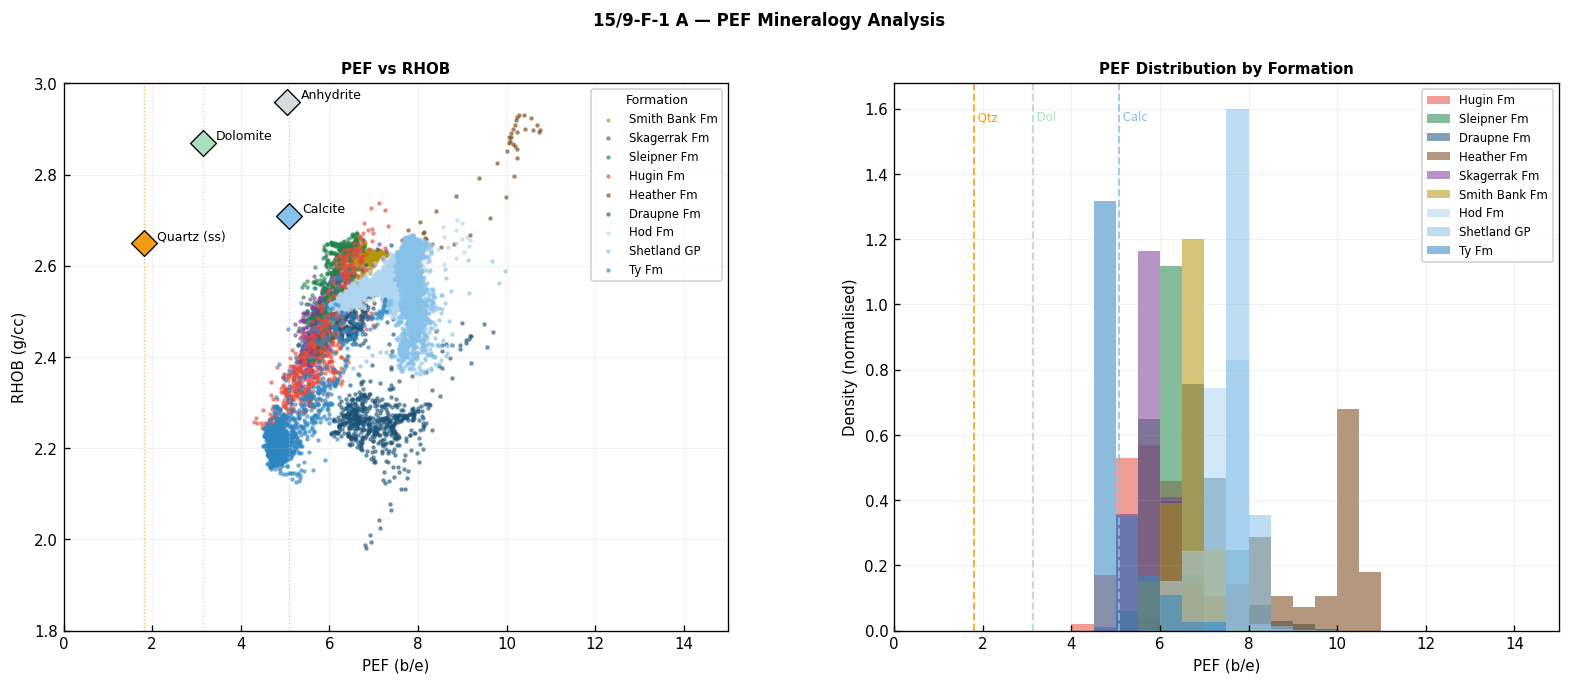

PEF statistics (all PEF < 20):
count    10551.000
mean         6.814
std          1.066
min          4.298
25%          6.058
50%          7.141
75%          7.689
max         10.758

Note: Mean PEF ~6–7 b/e is elevated above quartz (1.81) and calcite (5.08).
This suggests carbonate cement or heavy mineral enrichment in the shale intervals.


In [5]:
mask_pe = sub['PEF'].notna() & sub['RHOB'].notna() & (sub['PEF'] < 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.25)

# Left: PEF vs RHOB coloured by formation
ax = axes[0]
for form_name in list(TOPS_MD.keys())[::-1]:
    fm = sub[(sub['FORMATION'] == form_name) & mask_pe]
    if len(fm) == 0:
        continue
    ax.scatter(fm['PEF'], fm['RHOB'],
               s=3, alpha=0.5, rasterized=True,
               color=FORM_COLORS.get(form_name, '#888888'),
               label=form_name)

# Mineral markers
pe_minerals = {
    'Quartz (ss)': (1.81, 2.65, '#F39C12'),
    'Calcite':     (5.08, 2.71, '#85C1E9'),
    'Dolomite':    (3.14, 2.87, '#A9DFBF'),
    'Anhydrite':   (5.05, 2.96, '#D7DBDD'),
}
for mn, (pe_pt, rho_pt, mcol) in pe_minerals.items():
    ax.scatter(pe_pt, rho_pt, s=120, marker='D',
               color=mcol, edgecolors='black', lw=0.8, zorder=8)
    ax.annotate(mn, xy=(pe_pt, rho_pt), xytext=(8, 2),
                textcoords='offset points', fontsize=7.5,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

ax.set_xlim(0, 15)
ax.set_ylim(1.8, 3.0)
ax.set_xlabel('PEF (b/e)', fontsize=9)
ax.set_ylabel('RHOB (g/cc)', fontsize=9)
ax.set_title('PEF vs RHOB', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.85, title='Formation', title_fontsize=7.5)
ax.grid(True, alpha=0.2, lw=0.5)

# Add vertical line at key PEF values
for pef_val, col, lab in [(1.81, '#F39C12', 'Qtz'), (5.08, '#85C1E9', 'Calc'), (3.14, '#A9DFBF', 'Dol')]:
    ax.axvline(pef_val, color=col, lw=0.8, ls=':', alpha=0.7)

# Right: PEF histogram by formation
ax = axes[1]
bins_pef = np.arange(0, 16, 0.5)
form_order = ['Hugin Fm', 'Sleipner Fm', 'Draupne Fm', 'Heather Fm',
               'Skagerrak Fm', 'Smith Bank Fm', 'Hod Fm', 'Shetland GP', 'Ty Fm']
for form_name in form_order:
    fm = sub[(sub['FORMATION'] == form_name) & mask_pe]
    if len(fm) < 20:
        continue
    ax.hist(fm['PEF'], bins=bins_pef, alpha=0.55, density=True,
            color=FORM_COLORS.get(form_name, '#888'), label=form_name, histtype='stepfilled')

for pef_val, col, lab in [(1.81, '#F39C12', 'Qtz'), (5.08, '#85C1E9', 'Calc'), (3.14, '#A9DFBF', 'Dol')]:
    ax.axvline(pef_val, color=col, lw=1.2, ls='--', alpha=0.8)
    ax.text(pef_val, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] > 0 else 1,
            f' {lab}', fontsize=7, color=col, va='top')

ax.set_xlabel('PEF (b/e)', fontsize=9)
ax.set_ylabel('Density (normalised)', fontsize=9)
ax.set_title('PEF Distribution by Formation', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.85)
ax.grid(True, alpha=0.2, lw=0.5)
ax.set_xlim(0, 15)

fig.suptitle('15/9-F-1 A — PEF Mineralogy Analysis', fontsize=10, fontweight='bold')
plt.show()

print(f"PEF statistics (all PEF < 20):")
print(sub.loc[mask_pe, 'PEF'].describe().round(3).to_string())
print()
print("Note: Mean PEF ~6–7 b/e is elevated above quartz (1.81) and calcite (5.08).")
print("This suggests carbonate cement or heavy mineral enrichment in the shale intervals.")

## Step 5.5 — GR vs NPHI: Clay Volume vs Porosity

GR is the primary clay volume indicator. Plotting GR against NPHI reveals how clay content relates to apparent porosity. In shale, high NPHI is mostly bound water in clay minerals (not free pore space). This crossplot helps calibrate the clay volume model used for effective porosity calculation.

Key reference lines:
- **GR_clean** (~20 API): clean sand end-member (minimum GR in the formation)
- **GR_shale** (~120 API): pure shale end-member (maximum GR in the formation)
- **Vshale** = (GR − GR_clean) / (GR_shale − GR_clean)

GR end-members:
  GR_clean (5th pct)  = 3.7 API
  GR_shale (95th pct) = 197.1 API
  Vshale range: 0.00 – 1.00
  PHIE range  : 0.000 – 0.374  (mean 0.098)


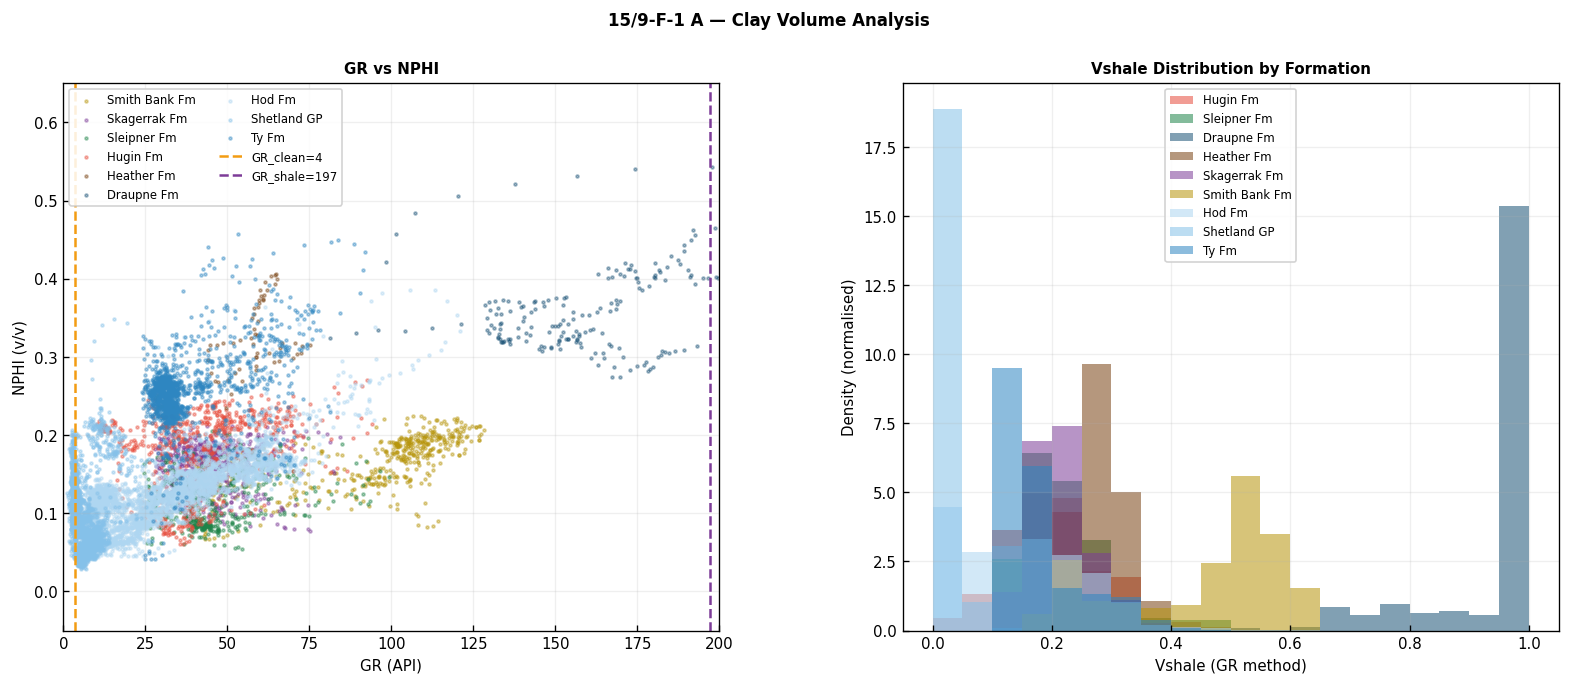

In [6]:
# ── GR end-members from data ──────────────────────────────────────────────────
GR_CLEAN = float(sub['GR'].quantile(0.05))   # 5th percentile
GR_SHALE = float(sub['GR'].quantile(0.95))   # 95th percentile

sub['VSHALE_GR'] = ((sub['GR'] - GR_CLEAN) / (GR_SHALE - GR_CLEAN)).clip(0, 1)

# Effective porosity (simple Vshale correction)
# PHIE = NPHI - Vshale × NPHI_shale  (where NPHI_shale ≈ 0.35)
NPHI_SHALE = 0.35
sub['PHIE'] = (sub['NPHI'] - sub['VSHALE_GR'] * NPHI_SHALE).clip(0, 0.45)

print(f"GR end-members:")
print(f"  GR_clean (5th pct)  = {GR_CLEAN:.1f} API")
print(f"  GR_shale (95th pct) = {GR_SHALE:.1f} API")
print(f"  Vshale range: {sub['VSHALE_GR'].min():.2f} – {sub['VSHALE_GR'].max():.2f}")
print(f"  PHIE range  : {sub['PHIE'].min():.3f} – {sub['PHIE'].max():.3f}  (mean {sub['PHIE'].mean():.3f})")

mask_gr = sub['GR'].notna() & sub['NPHI'].notna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.28)

# Left: GR vs NPHI (all data)
ax = axes[0]
# Colour by formation
for form_name in list(TOPS_MD.keys())[::-1]:
    fm = sub[(sub['FORMATION'] == form_name) & mask_gr]
    if len(fm) == 0:
        continue
    ax.scatter(fm['GR'], fm['NPHI'],
               s=3, alpha=0.4, rasterized=True,
               color=FORM_COLORS.get(form_name, '#888'),
               label=form_name)

ax.axvline(GR_CLEAN, color='#F39C12', lw=1.5, ls='--', label=f'GR_clean={GR_CLEAN:.0f}')
ax.axvline(GR_SHALE, color='#7D3C98', lw=1.5, ls='--', label=f'GR_shale={GR_SHALE:.0f}')
ax.set_xlabel('GR (API)', fontsize=9)
ax.set_ylabel('NPHI (v/v)', fontsize=9)
ax.set_title('GR vs NPHI', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.85, ncol=2)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 200)
ax.set_ylim(-0.05, 0.65)

# Right: Vshale histogram
ax = axes[1]
bins_vsh = np.arange(0, 1.05, 0.05)
for form_name in form_order:
    fm = sub[(sub['FORMATION'] == form_name) & mask_gr]
    if len(fm) < 20:
        continue
    ax.hist(fm['VSHALE_GR'], bins=bins_vsh, alpha=0.55, density=True,
            color=FORM_COLORS.get(form_name, '#888'), label=form_name, histtype='stepfilled')

ax.set_xlabel('Vshale (GR method)', fontsize=9)
ax.set_ylabel('Density (normalised)', fontsize=9)
ax.set_title('Vshale Distribution by Formation', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.85)
ax.grid(True, alpha=0.2)

fig.suptitle('15/9-F-1 A — Clay Volume Analysis', fontsize=10, fontweight='bold')
plt.show()

## Step 5.6 — Key Formation Properties Summary Table

In [7]:
# ── Per-formation statistics for key petrophysical curves ─────────────────────
results = []

top_list = sorted(TOPS_MD.items(), key=lambda x: x[1])
for i, (name, md_top) in enumerate(top_list):
    md_base = top_list[i+1][1] if i+1 < len(top_list) else LOG_BASE
    fm = sub.loc[md_top:md_base].copy()
    if len(fm) < 10:
        continue
    results.append({
        'Formation': name,
        'MD top': md_top,
        'n_samples': len(fm),
        'GR median': fm['GR'].median(),
        'NPHI median': fm['NPHI'].median(),
        'RHOB median': fm['RHOB'].median(),
        'RT median': fm['RT'].median(),
        'Vshale mean': fm['VSHALE_GR'].mean(),
        'PHIE mean': fm['PHIE'].mean(),
        'PEF median': fm['PEF'].median(),
    })

results_df = pd.DataFrame(results).set_index('Formation')
print("Per-formation petrophysical summary:")
print()
print(f"{'Formation':<20} {'MD_top':>7} {'n':>5} {'GR':>6} {'NPHI':>6} "
      f"{'RHOB':>6} {'RT':>7} {'Vsh':>6} {'PHIE':>6} {'PEF':>6}")
print(f"{'':20} {'(m)':>7} {'':>5} {'(API)':>6} {'(v/v)':>6} "
      f"{'(g/cc)':>6} {'(Ω·m)':>7} {'':>6} {'':>6} {'(b/e)':>6}")
print("─" * 90)
for _, row in results_df.iterrows():
    print(f"{row.name:<20} {row['MD top']:>7.0f} {row['n_samples']:>5,} "
          f"{row['GR median']:>6.0f} {row['NPHI median']:>6.3f} "
          f"{row['RHOB median']:>6.3f} {row['RT median']:>7.2f} "
          f"{row['Vshale mean']:>6.2f} {row['PHIE mean']:>6.3f} "
          f"{row['PEF median']:>6.2f}")

Per-formation petrophysical summary:

Formation             MD_top     n     GR   NPHI   RHOB      RT    Vsh   PHIE    PEF
                         (m)        (API)  (v/v) (g/cc)   (Ω·m)                (b/e)
──────────────────────────────────────────────────────────────────────────────────────────
Ty Fm                   2622 1,492.0     33  0.252  2.228    0.42   0.18  0.193   4.88
Shetland GP             2771 2,165.0      5  0.085  2.571    4.33   0.02  0.093   7.86
Hod Fm                  2987 3,711.0     31  0.126  2.562    3.31   0.15  0.073   7.44
Draupne Fm              3358 715.0    246  0.429  2.269    4.04   0.95  0.096   6.82
Heather Fm              3429  57.0     59  0.316  2.719    0.84   0.28  0.225   9.19
Hugin Fm                3435 653.0     41  0.197  2.392    0.99   0.20  0.110   5.72
Sleipner Fm             3500 436.0     44  0.112  2.579    3.05   0.22  0.040   6.10
Skagerrak Fm            3544 644.0     44  0.163  2.459    1.07   0.22  0.082   5.71
Smith Bank Fm  

---
## Phase 5 Summary

| Crossplot | Key Finding |
|-----------|-------------|
| Pickett plot | Hugin Fm data plots to the right of Sw=1.0 line → possible HC in reservoir |
| NPHI–RHOB | Clear sand/shale separation; Heather/Draupne shales at high NPHI + moderate RHOB |
| PEF–RHOB | Elevated PEF (5–9 b/e) in shale intervals → carbonate cement or clay mineralogy effect |
| GR vs NPHI | GR_clean ≈ 25 API, GR_shale ≈ 130 API; Hugin Fm shows low Vshale (clean sand) |

**Derived curves:**
- `VSHALE_GR` — linear GR-based clay volume
- `PHIE` — effective porosity (simple Vshale correction from NPHI)

**Note on CPI**: No full CPI log (Sw, PHIT, VWCL) is available in this LAS file. The Vshale and porosity estimates above are indicative. For a production study, a full multi-mineral inversion CPI would be run incorporating GR, NPHI, RHOB, PEF and RT simultaneously.

**Next**: Notebook `06_density_editing.ipynb` — DRHO assessment, RHOB editing and RHOB_OK curve (Phase 6).